Using device: cuda
图像 batch 形状: torch.Size([64, 1, 32, 32])
标签 batch 形状: torch.Size([64])
像素值范围: [-0.424, 2.821]


/tmp/ipykernel_1331644/3724628056.py:43: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1331644/3724628056.py:43: UserWarning: Glyph 31614 (\N{CJK UNIFIED IDEOGRAPH-7B7E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/v-houzhiyuan/miniconda3/envs/dl_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/v-houzhiyuan/miniconda3/envs/dl_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 31614 (\N{CJK UNIFIED IDEOGRAPH-7B7E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


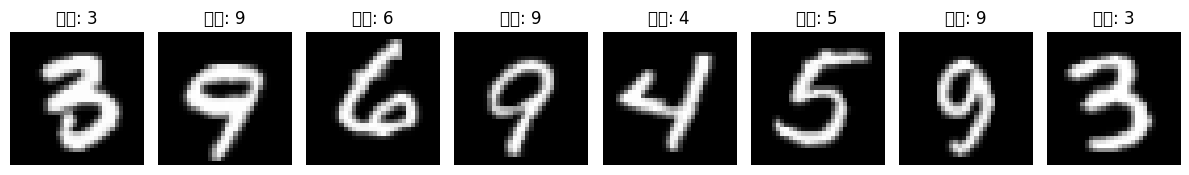

In [1]:
import torch
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

transform = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor(),                        
    transforms.Normalize((0.1307,), (0.3081,))      
])

train_dataset = torchvision.datasets.MNIST(
    root='./data',      
    train=True,           
    transform=transform,   
    download=True          
)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=64,
    shuffle=True,       
    num_workers=2
)

# 验证：查看一个 batch 的形状
images, labels = next(iter(train_loader))
print(f"图像 batch 形状: {images.shape}")   
print(f"标签 batch 形状: {labels.shape}")    # [64]
print(f"像素值范围: [{images.min():.3f}, {images.max():.3f}]")   # 归一化后约为 [-0.42, 2.82]

# 可视化前 8 张图
fig, axes = plt.subplots(1, 8, figsize=(12, 3))
for i in range(8):
    img = images[i].squeeze(0)  
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"标签: {labels[i].item()}")
    axes[i].axis('off')
plt.tight_layout()
plt.show()

In [2]:
import model
import torch.optim as optim
import numpy as np

T = 1000
Model = model.Diffusion(T).to(device)
optimizer = optim.Adam(Model.parameters(), lr=0.001, weight_decay=1e-4)

# train
num_epochs = 30
for epochs in range(num_epochs):
    Losssum = 0
    for images, labels in train_loader:
        images = images.to(device)
        labels=labels.to(device)
        t = np.random.randint(1, T, size=images.shape[0])
        t = torch.tensor(t, device=device)
        Loss = Model(images, t,labels)
        Losssum += Loss

        optimizer.zero_grad()
        Loss.backward()
        optimizer.step()
    print(epochs,Losssum)

0 tensor(63.3397, device='cuda:0', grad_fn=<AddBackward0>)
1 tensor(35.5231, device='cuda:0', grad_fn=<AddBackward0>)
2 tensor(32.1117, device='cuda:0', grad_fn=<AddBackward0>)
3 tensor(30.1349, device='cuda:0', grad_fn=<AddBackward0>)
4 tensor(28.8853, device='cuda:0', grad_fn=<AddBackward0>)
5 tensor(27.6631, device='cuda:0', grad_fn=<AddBackward0>)
6 tensor(27.8499, device='cuda:0', grad_fn=<AddBackward0>)
7 tensor(27.3680, device='cuda:0', grad_fn=<AddBackward0>)
8 tensor(26.4761, device='cuda:0', grad_fn=<AddBackward0>)
9 tensor(25.9141, device='cuda:0', grad_fn=<AddBackward0>)
10 tensor(26.3249, device='cuda:0', grad_fn=<AddBackward0>)
11 tensor(26.0246, device='cuda:0', grad_fn=<AddBackward0>)
12 tensor(25.4776, device='cuda:0', grad_fn=<AddBackward0>)
13 tensor(25.5888, device='cuda:0', grad_fn=<AddBackward0>)
14 tensor(25.5871, device='cuda:0', grad_fn=<AddBackward0>)
15 tensor(25.3023, device='cuda:0', grad_fn=<AddBackward0>)
16 tensor(25.3131, device='cuda:0', grad_fn=<AddBa

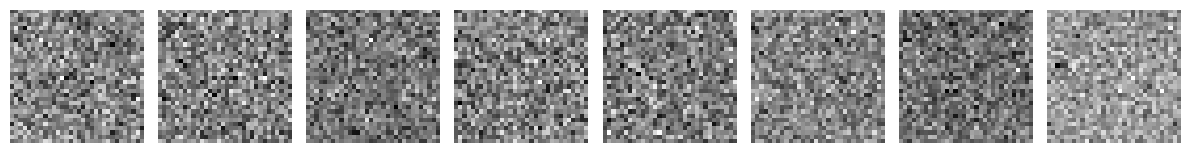

tensor([6, 8, 2, 4, 5, 3, 5, 1], device='cuda:0')


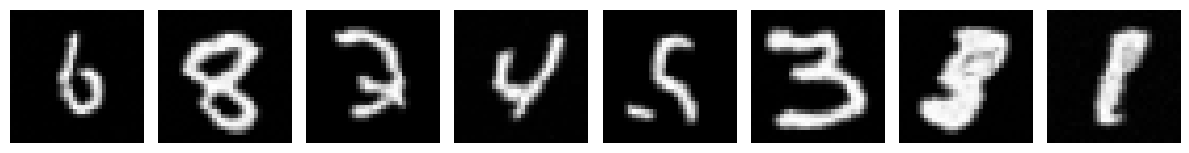

In [3]:
# eval
X = torch.randn([64, 1, 32, 32], device=device)

X_cpu = X.cpu()
fig, axes = plt.subplots(1, 8, figsize=(12, 3))
for i in range(8):
    img = X_cpu[i].squeeze(0)  
    img_vis=img * 0.3081 + 0.1307
    axes[i].imshow(img_vis, cmap='gray')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

with torch.no_grad(): # 测试要加上，不然建立巨大计算图
    val = np.random.randint(0,10,size=64)
    val = torch.tensor(val, device=device)
    for i in range(T - 1, 0, -1):
        t = torch.full((64,), i, device=device)
        X = Model.step(X, t,val)

# 将结果移回 CPU 用于绘图
X_cpu = X.cpu()
fig, axes = plt.subplots(1, 8, figsize=(12, 3))
print(val[0:8])
for i in range(8):
    img = X_cpu[i].squeeze(0)  
    img_vis=img * 0.3081 + 0.1307
    axes[i].imshow(img_vis, cmap='gray')
    axes[i].axis('off')
plt.tight_layout()
plt.show()